# Dreamer Testing

Idea in this notebook is to implement an RSSM for use in the Dreamer V2 and V3 architectures. And then to test a simple training loop.

In [1]:
import jax.numpy as jnp
from flax import nnx

from dreamer.wm import DreamerConfig, DreamerWM

cfg = DreamerConfig()
dreamer = DreamerWM(cfg, rngs=nnx.Rngs(0))

In [2]:
BATCH_SIZE = 2  # num_sequences
SEQ_LENGTH = 4

# training notes - sample start index uniformly, and truncate samples which go beyond
# the end of the episode (as opposed to only sampling up to T - 50)
# beyond episode end, set the discount factor gamma -> 0

In [3]:
from dreamer.wm.world_model import DreamerBatch

rngs = nnx.Rngs(0)
imgs = rngs.normal((BATCH_SIZE, SEQ_LENGTH, 64, 64, 3))
reward = rngs.normal((BATCH_SIZE, SEQ_LENGTH))
discount = rngs.normal((BATCH_SIZE, SEQ_LENGTH))
action = rngs.normal((BATCH_SIZE, SEQ_LENGTH, 3))
is_first = jnp.zeros((BATCH_SIZE, SEQ_LENGTH), dtype=jnp.bool)
is_first = is_first.at[:, 0].set(True)
is_first = is_first.at[:, 6].set(True)

batch = DreamerBatch(
    image=imgs, reward=reward, discount=discount, prev_action=action, is_first=is_first
)

In [4]:
from dreamer.wm.losses import dreamer_wm_loss_fn


@nnx.value_and_grad(has_aux=True)
def loss_fn(model, batch):
    losses = dreamer_wm_loss_fn(model, batch, cfg.kl_alpha)
    loss = (
        cfg.kl_beta * losses.kl_loss
        + losses.discount_loss
        + losses.reward_loss
        + losses.image_loss
    )
    return loss, losses


@nnx.jit
def train_step(model, batch, optim):
    (loss, sub_losses), grads = loss_fn(model, batch)
    optim.update(model, grads)
    return loss, sub_losses

In [5]:
import optax

lr = 5e-4
tx = optax.adamw(lr)
optim = nnx.Optimizer(dreamer, tx, wrt=nnx.Param)

losses = []
for i in range(200):
    loss, sub_losses = train_step(dreamer, batch, optim)
    losses.append(loss)

Ships Whistle:style=italic:variant=normal:weight=normal:stretch=normal:size=15.6


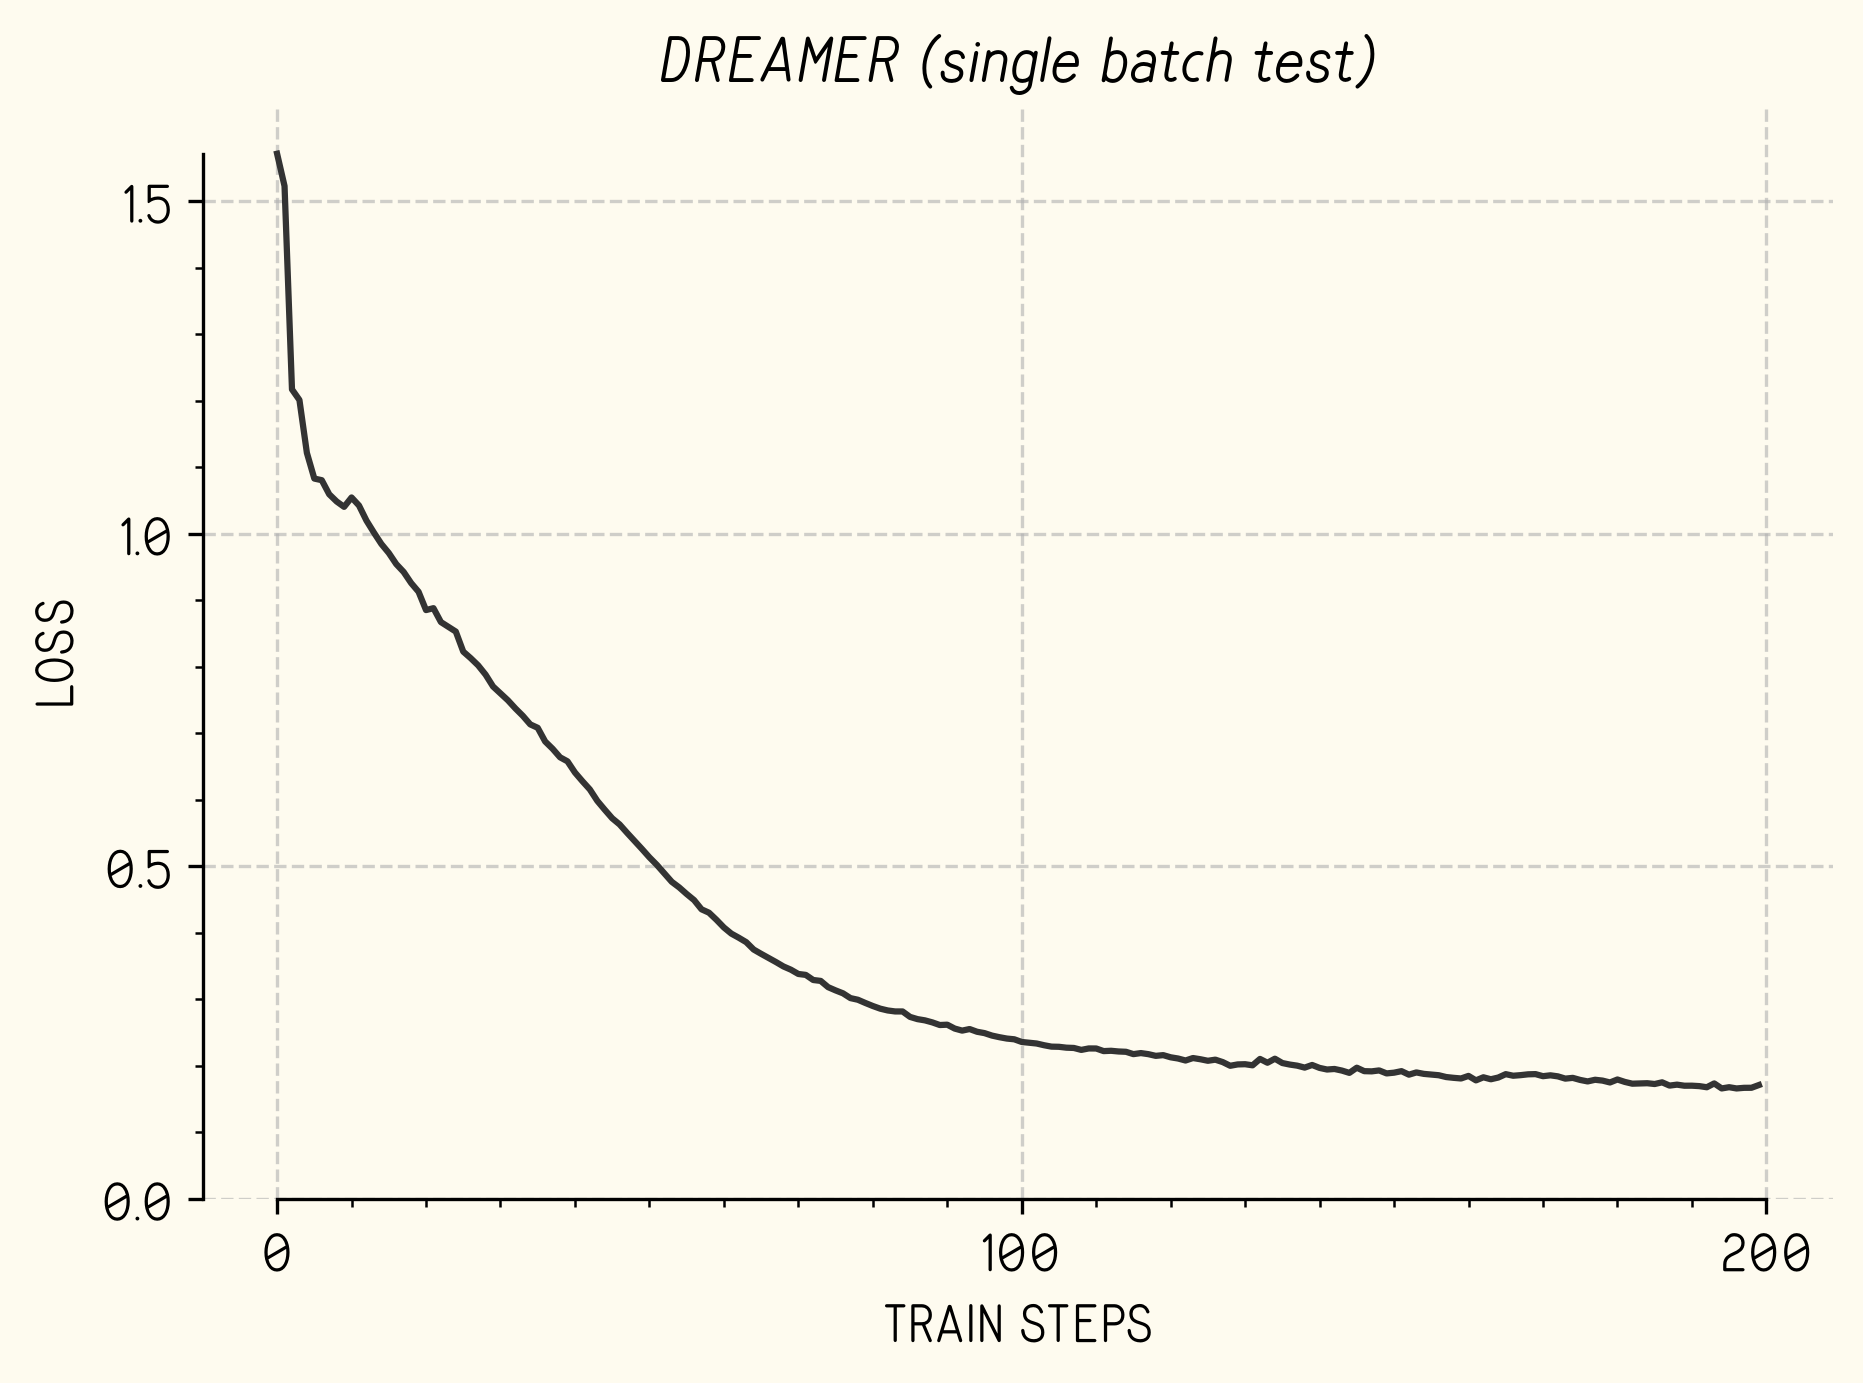

In [6]:
import matplotlib.pyplot as plt

blk = "#333333"
off_white = "#FEFBEF"

plt.rcParams["font.family"] = "Ships Whistle"
plt.rcParams["font.style"] = "normal"
plt.rcParams["font.size"] = 13
plt.rcParams["figure.facecolor"] = off_white
plt.rcParams["axes.facecolor"] = off_white
plt.rcParams["figure.dpi"] = 300


losses = jnp.array(losses)

fig, ax = plt.subplots()
ax.plot(losses, c=blk, linewidth=1.5)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_bounds(0, losses.max())
ax.spines["bottom"].set_bounds(0, len(losses))

ax.xaxis.set_ticks(jnp.arange(0, 201, 100), minor=False)
ax.xaxis.set_ticks(jnp.arange(0, 201, 10), minor=True)


ax.yaxis.set_ticks(jnp.arange(0, losses.max() + 0.05, 0.5), minor=False)
ax.yaxis.set_ticks(jnp.arange(0, losses.max(), 0.1), minor=True)

ax.xaxis.set_label_text("TRAIN STEPS")
ax.yaxis.set_label_text("LOSS")

ax.annotate(f"{losses.min():.2f}", (500 + 6, losses.min() - 0.045))

ax.set_title(
    "DREAMER (single batch test)",
    fontstyle="italic",
    # fontfeatures=["ss01[0]"],
)

plt.grid(alpha=0.6, linestyle="--")
print(ax.title.get_fontproperties())
plt.tight_layout()
plt.savefig("../assets/dummy_batch.png")
plt.show()

TODO: Write the appropriate dataloader/env interaction loop setup 
- off-by-one actions
- packing into full sequence length
- is_first bools (on the right step)
- symlog?
- Exponential bins...
- God there's a lot to compute yet...
- binary cross-entropy for the discount predictor (how does v3 do this? Doesn't it just predict episode end directly rather than discount? YES - "continue predictor")


TODO: Train the world model in contact with a random policy, verify that it works (and each individual component works)
TODO: Write the actor-critic implementation

In [18]:
import gymnasium as gym
import jax
import numpy as np
from jaxtyping import Array, Float
from loguru import logger

from dreamer.buffer import add_episodes, get_batch, init_buffer
from wm.utils import prep_obs

NUM_ENVS = 4
MAX_TIMESTEPS = 1000

envs = gym.make_vec("CarRacing-v3", num_envs=NUM_ENVS, vectorization_mode="async")

# technically this function will overfill, which is cheeky, but it doesn't matter
num_eps = 6
buffer = init_buffer(num_eps)


def policy(obs: Float[Array, "B H W C"], key: Array):
    del obs

    minvals = jnp.array([-1, 0, 0])
    maxvals = jnp.array([1, 1, 1])
    return jax.random.uniform(key, shape=(NUM_ENVS, 3), minval=minvals, maxval=maxvals)


logger.info("Collecting rollouts")

rngs = nnx.Rngs(0)
for ep_ix in range(0, num_eps, NUM_ENVS):
    rollout_obs = np.empty(shape=(NUM_ENVS, 1000, 64, 64, 3))
    rollout_acts = np.empty(shape=(NUM_ENVS, 1000, 3))
    rollout_discounts = np.empty(shape=(NUM_ENVS, 1000))
    rollout_rewards = np.empty(shape=(NUM_ENVS, 1000))

    obs, _ = envs.reset(seed=ep_ix * 250)

    finished = False
    for t in range(MAX_TIMESTEPS):
        acts = policy(obs, rngs())
        obs, rwds, terminated, truncated, _infos = envs.step(np.array(acts))

        # TODO: process obs, rewards and acts properly
        rollout_obs[:NUM_ENVS, t] = prep_obs(obs[:, :64, :64, :])
        rollout_acts[:NUM_ENVS, t] = acts
        rollout_discounts[:NUM_ENVS, t] = 0.997
        rollout_rewards[:NUM_ENVS, t] = rwds[0]

    buffer = add_episodes(
        buffer,
        rollout_obs,
        rollout_acts,
        rollout_discounts,
        rollout_rewards,
    )

2026-09-17 15:27:15.072 | INFO     | __main__:<module>:28 - Collecting rollouts


In [17]:
buffer

BufferState(cursor=Array(2, dtype=int32), full=Array(True, dtype=bool), obs=Array([[[[[  0.,   0.,   0.],
          [  0.,   0.,   0.],
          [  0.,   0.,   0.],
          ...,
          [  0.,   0.,   0.],
          [  0.,   0.,   0.],
          [  0.,   0.,   0.]],

         [[  0.,   0.,   0.],
          [  0.,   0.,   0.],
          [  0.,   0.,   0.],
          ...,
          [  0.,   0.,   0.],
          [  0.,   0.,   0.],
          [  0.,   0.,   0.]],

         [[  0.,   0.,   0.],
          [  0.,   0.,   0.],
          [  0.,   0.,   0.],
          ...,
          [  0.,   0.,   0.],
          [  0.,   0.,   0.],
          [  0.,   0.,   0.]],

         ...,

         [[100., 202., 100.],
          [100., 205., 100.],
          [100., 203., 100.],
          ...,
          [  0.,   0.,   0.],
          [  0.,   0.,   0.],
          [  0.,   0.,   0.]],

         [[100., 202., 100.],
          [100., 202., 100.],
          [100., 202., 100.],
          ...,
          [  0.,

In [9]:
from dreamer.wm.world_model import DreamerWMOut


class ActorCritic(nnx.Module):
    def __init__(self, cfg: DreamerConfig, rngs: nnx.Rngs):
        # shared backbone -> actor + critic
        input_dim = cfg.latent_dim + cfg.wm_hidden_dim + cfg.action_dim

        self.backbone = nnx.Sequential(
            nnx.Linear(input_dim, cfg.agent_hidden_dim, rngs=rngs),
            cfg.activation_fn,
            nnx.Linear(cfg.agent_hidden_dim, cfg.agent_hidden_dim, rngs=rngs),
            cfg.activation_fn,
        )  # type: ignore

        self.actor_head = nnx.Linear(cfg.agent_hidden_dim, cfg.action_dim, rngs=rngs)
        self.critic_head = nnx.Linear(cfg.agent_hidden_dim, 1, rngs=rngs)

    def __call__(
        self, wm_out: DreamerWMOut, prev_action: Float[Array, "... ActionDim"]
    ) -> tuple[Array, Array]:
        z = jnp.concat([wm_out.hidden, wm_out.latent_sample, prev_action], axis=-1)
        z = self.backbone(z)

        # Predict action and squeeze into [-1:1, 0:1, 0:1]
        action_pred = self.actor_head(z)
        action_pred = nnx.sigmoid(action_pred)
        action_pred = action_pred.at[..., 0].set(action_pred[..., 0] * 2 - 1)

        value_pred = self.critic_head(z)  # idk if we need to transform this at all?

        return action_pred, value_pred

    @staticmethod
    def loss_fn(
        cfg: DreamerConfig,
        rewards: Float[Array, "B T"],
        values: Float[Array, "B T"],
    ):
        discount = cfg.discount
        lam = cfg.td_lambda

        # TODO: check if this is actually how you compute TD lambda :)
        # TODO: add stopgradient
        # Compute the TD(lambda) return from the final state, summing backwards recursively
        @nnx.scan(
            in_axes=(1, 1, nnx.Carry),
            out_axes=(1, nnx.Carry),
            reverse=True,
        )
        def compute_lambda_return(r_t: Array, v_t1: Array, G_t1: Array):
            v_t1_sg = jax.lax.stop_gradient(v_t1)
            G_t = r_t + discount * ((1 - lam) * v_t1_sg + lam * G_t1)
            # first output stores the results per-timestep, the second acts as the carry
            return G_t, G_t

        carry = values[..., -1]  # take final timestep as the initial value
        target, _ = compute_lambda_return(rewards, values, carry)

        # Returned grad will be both the grad of G_t and the MSBE
        # TODO: check gradient correctness - what do I actually want for policy gradients?
        value_loss = optax.losses.squared_error(target, values)

        # policy_loss = ...

        return {
            "value_loss": value_loss,
            "target": target,
            "loss": value_loss.mean() + target.mean(),
        }

In [10]:
# options

# Scan forwards over episode/imagination to produce trajectory (actions [B T A], values [B T])
# Scan backwards to compute TD lambda targets
# Compute gradients using TD lambda targets
ac = ActorCritic(cfg, nnx.Rngs(0))
ac.loss_fn(cfg, batch.reward, batch.reward)
# ActorCritic.loss_fn(cfg, batch.reward, batch.reward)

{'value_loss': Array([[7.5690937e-01, 7.3697132e-01, 7.1506476e-01, 6.9104040e-01,
         6.6475004e-01, 6.3605136e-01, 6.0481399e-01, 5.7092798e-01,
         5.3431463e-01, 4.9494013e-01, 4.5283440e-01, 4.0811452e-01,
         3.6101505e-01, 3.1192631e-01, 2.6144388e-01, 2.1043059e-01,
         1.6009557e-01, 1.1209362e-01, 6.8650588e-02, 3.2721192e-02,
         8.1870928e-03, 1.0552263e-04, 1.5020772e-02, 6.1354216e-02,
         1.4989215e-01, 2.9439560e-01, 5.1236171e-01, 8.2597452e-01,
         1.2632915e+00, 1.8597217e+00, 2.6598694e+00, 3.7198329e+00,
         5.1100626e+00, 2.5443020e-01, 6.3894814e-01, 6.0796267e-01,
         5.7433796e-01, 5.3799176e-01, 4.9888530e-01, 4.5704144e-01,
         4.1256744e-01, 3.6568484e-01, 3.1676698e-01, 2.6638696e-01,
         2.1537843e-01, 1.6491300e-01, 1.1659704e-01, 7.2594665e-02,
         3.5781816e-02, 9.9400897e-03],
        [9.3408912e-01, 9.3313682e-01, 9.3207610e-01, 9.3089473e-01,
         9.2957914e-01, 9.2811382e-01, 9.2648238e